In [64]:
import pandas as pd

In [65]:
from urllib.request import urlretrieve

In [66]:
medical_charges_url = 'https://github.com/JovianHQ/opendatasets/blob/master/data/medical-charges.csv'

In [67]:
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x22dfa2043e0>)

In [68]:
medical_df = pd.read_csv(r"C:\Users\PRATHAMESH\Desktop\Data Science\medical-charges.csv")

In [69]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [70]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [71]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [72]:
!pip install matplotlib seaborn --quiet

In [73]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [74]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']= 14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor'] ='#00000000'

In [75]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

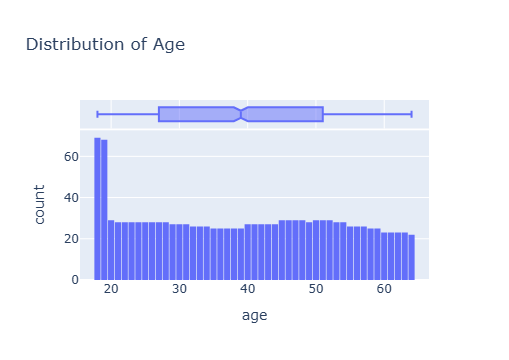

In [76]:
fig = px.histogram(medical_df,
                      x='age',
                      marginal = 'box',
                      nbins = 47,
                      title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

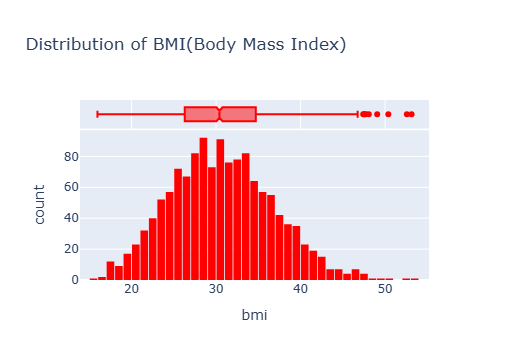

In [77]:
fig = px.histogram(medical_df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence =['red'],
                   title = 'Distribution of BMI(Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

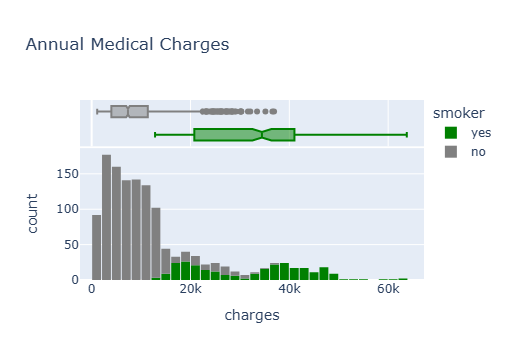

In [78]:
fig = px.histogram(medical_df,
                   x = 'charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green','grey'],
                   title='Annual Medical Charges' )
fig.update_layout(bargap=0.1)
fig.show()

In [79]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

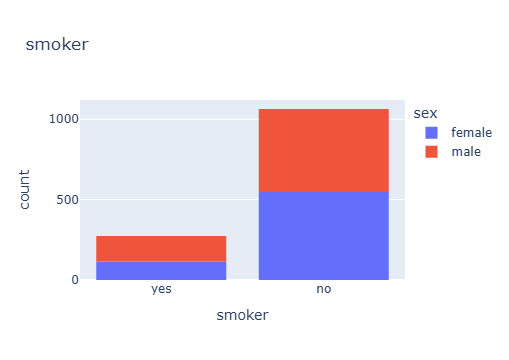

In [80]:
px.histogram(medical_df, x= 'smoker', color ='sex', title='smoker')

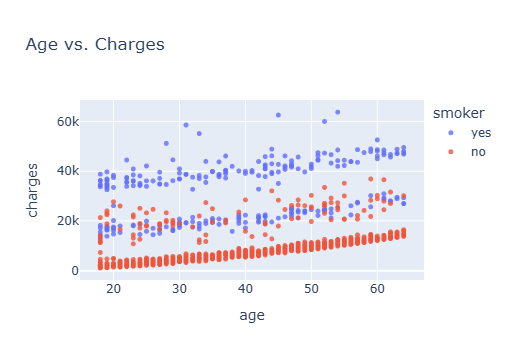

In [81]:
fig = px.scatter(medical_df,
                x='age',
                y='charges',
                color='smoker',
                opacity=0.8,
                hover_data = ['sex'],
                title='Age vs. Charges')
fig.update_traces(marker_size = 5)
fig.show()

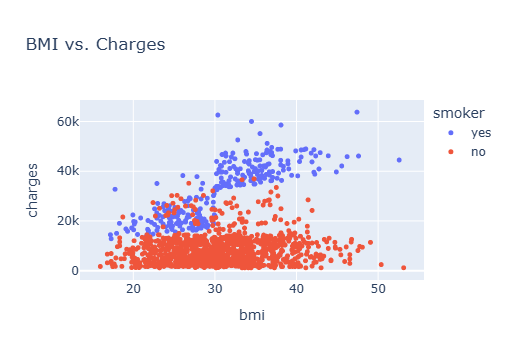

In [82]:
fig = px.scatter(medical_df,
                x='bmi',
                y='charges',
                color='smoker',
                hover_data='sex',
                title='BMI vs. Charges')
fig.update_traces(marker_size= 5)
fig.show()

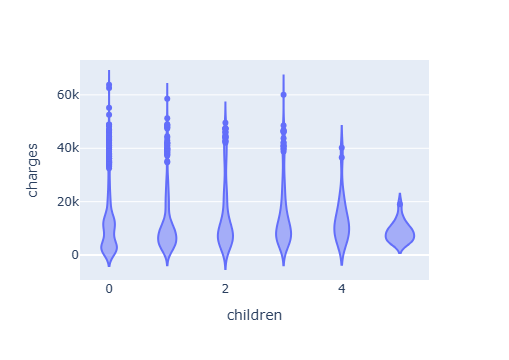

In [83]:
px.violin(medical_df,
          x='children',
          y='charges')

In [84]:
medical_df.charges.corr(medical_df.age)
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [85]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362884)

In [86]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790487)

In [87]:
smoker_values = {'no': 0, 'yes':1}
smoker_numeric = medical_df.smoker.map(smoker_values)



In [95]:
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [89]:
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984767)

In [93]:
medical_df.corr(numeric_only = True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'correlation matrix')

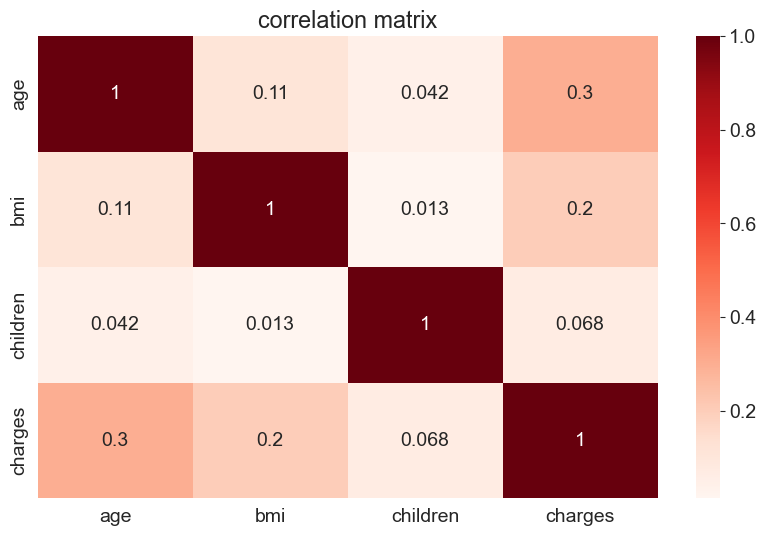

In [94]:
sns.heatmap(medical_df.corr(numeric_only = True),cmap='Reds', annot=True)
plt.title('correlation matrix')

In [96]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

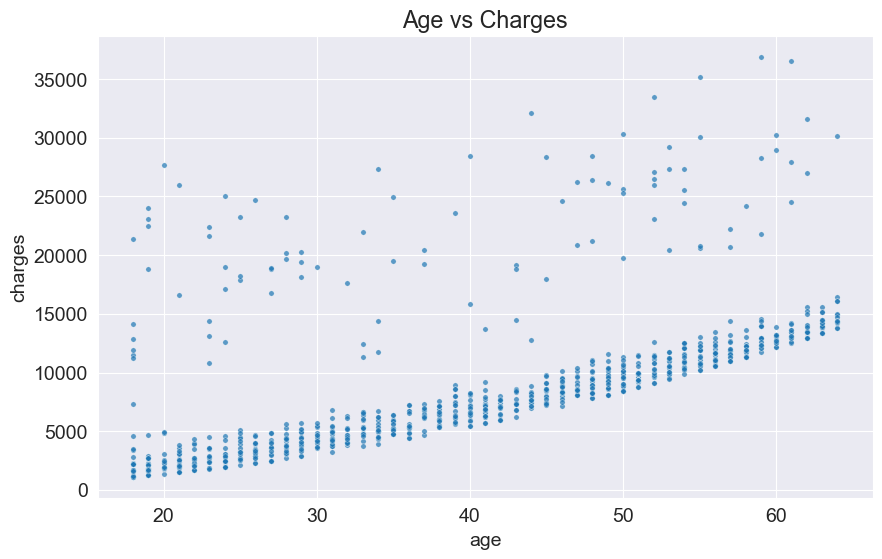

In [98]:
plt.title('Age vs Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges',alpha=0.7, s=15);

In [99]:
def estimate_charges(age,w,b):
    return w * age + b

In [107]:
w = 50
b = 100

In [109]:
estimate_charges(40,w,b)

2100

In [111]:
ages = non_smoker_df.age
ages

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [112]:
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages,w,b)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [113]:
non_smoker_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

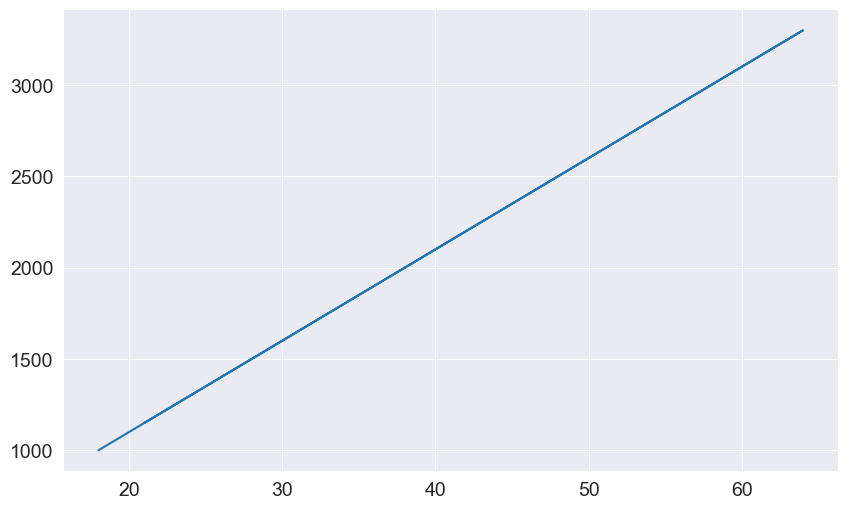

In [105]:
plt.plot(ages, estimate_charges(ages,w,b))